# Prediksi Diagnosis

Nama  : Hadhist Rizqi Fauzhi

NIM   : 250401020093

Kelas : IF405

### Load Dataset dan EDA Singkat

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target  # 0 = Malignant, 1 = Benign

# Menampilkan ukuran data
print("Shape:", X.shape)

# Menampilkan distribusi target
target_dist = pd.Series(y).replace({
    0: "Malignant",
    1: "Benign"
}).value_counts(normalize=True).round(3)

print("\nDistribusi Target:")
print(target_dist)

Shape: (569, 30)

Distribusi Target:
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


Analisis Awal Dataset

Dataset Breast Cancer Wisconsin terdiri dari 569 observasi dan 30 fitur numerik yang menggambarkan karakteristik sel, seperti radius, tekstur, perimeter, dan area.

Distribusi target menunjukkan bahwa data kategori Benign (jinak) lebih banyak dibandingkan Malignant (ganas). Proporsi data yang cukup seimbang membuat dataset ini sesuai digunakan untuk membangun model klasifikasi biner.

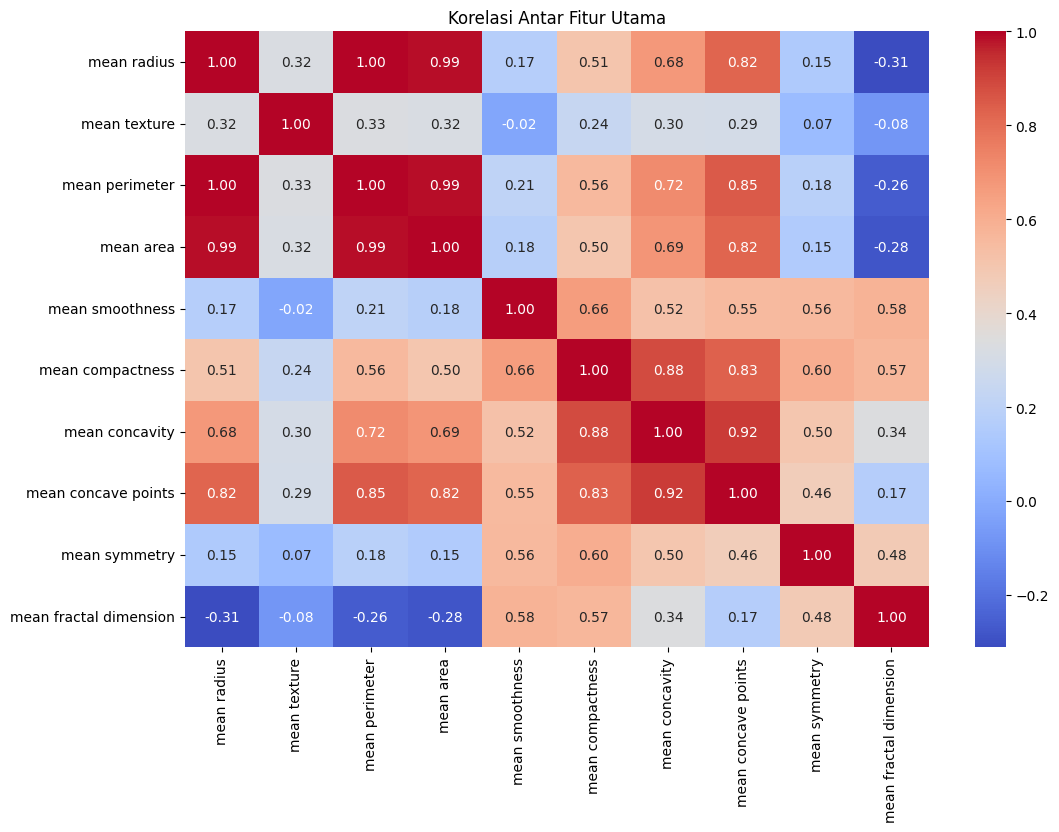

In [2]:
# Melihat korelasi antar fitur utama
plt.figure(figsize=(12, 8))

corr = X.corr()

sns.heatmap(
    corr.iloc[:10, :10],
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasi Antar Fitur Utama")
plt.show()

Interpretasi Korelasi

Beberapa fitur menunjukkan hubungan yang cukup kuat, terutama fitur yang berkaitan dengan ukuran sel, seperti radius, perimeter, dan area. Hal ini mengindikasikan bahwa karakteristik ukuran dan bentuk sel memiliki peran penting dalam membedakan sel kanker ganas dan sel jinak.

### Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran Data Training :", X_train.shape)
print("Ukuran Data Testing :", X_test.shape)

# Standardisasi fitur
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Ukuran Data Training : (455, 30)
Ukuran Data Testing : (114, 30)


Penjelasan Preprocessing

Data dibagi menjadi data training sebesar 80% dan data testing sebesar 20%. Parameter `stratify=y` digunakan agar proporsi data Malignant dan Benign tetap terjaga pada kedua kelompok data.

Setelah itu dilakukan standardisasi fitur menggunakan StandardScaler. Tahap ini diperlukan karena Logistic Regression sensitif terhadap perbedaan skala antar fitur.

### Melatih Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression

# Membuat model Logistic Regression
log_model = LogisticRegression(max_iter=5000)

# Melatih model
log_model.fit(X_train_s, y_train)

# Melakukan prediksi
y_pred_log = log_model.predict(X_test_s)

In [5]:
# Menampilkan koefisien fitur
coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Koefisien",
    key=abs,
    ascending=False
)

coef_df.head(10)

,Fitur,Koefisien
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


Interpretasi Logistic Regression

Fitur dengan nilai koefisien terbesar secara absolut merupakan fitur yang paling memengaruhi hasil prediksi model.

Secara umum, fitur seperti radius, perimeter, area, dan concave points sering muncul sebagai fitur yang paling berpengaruh. Hal tersebut menunjukkan bahwa ukuran dan bentuk sel menjadi indikator penting dalam proses diagnosis kanker payudara.

### Melatih Decision Tree

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Membuat model Decision Tree
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Melatih model
tree_model.fit(X_train, y_train)

# Melakukan prediksi
y_pred_tree = tree_model.predict(X_test)

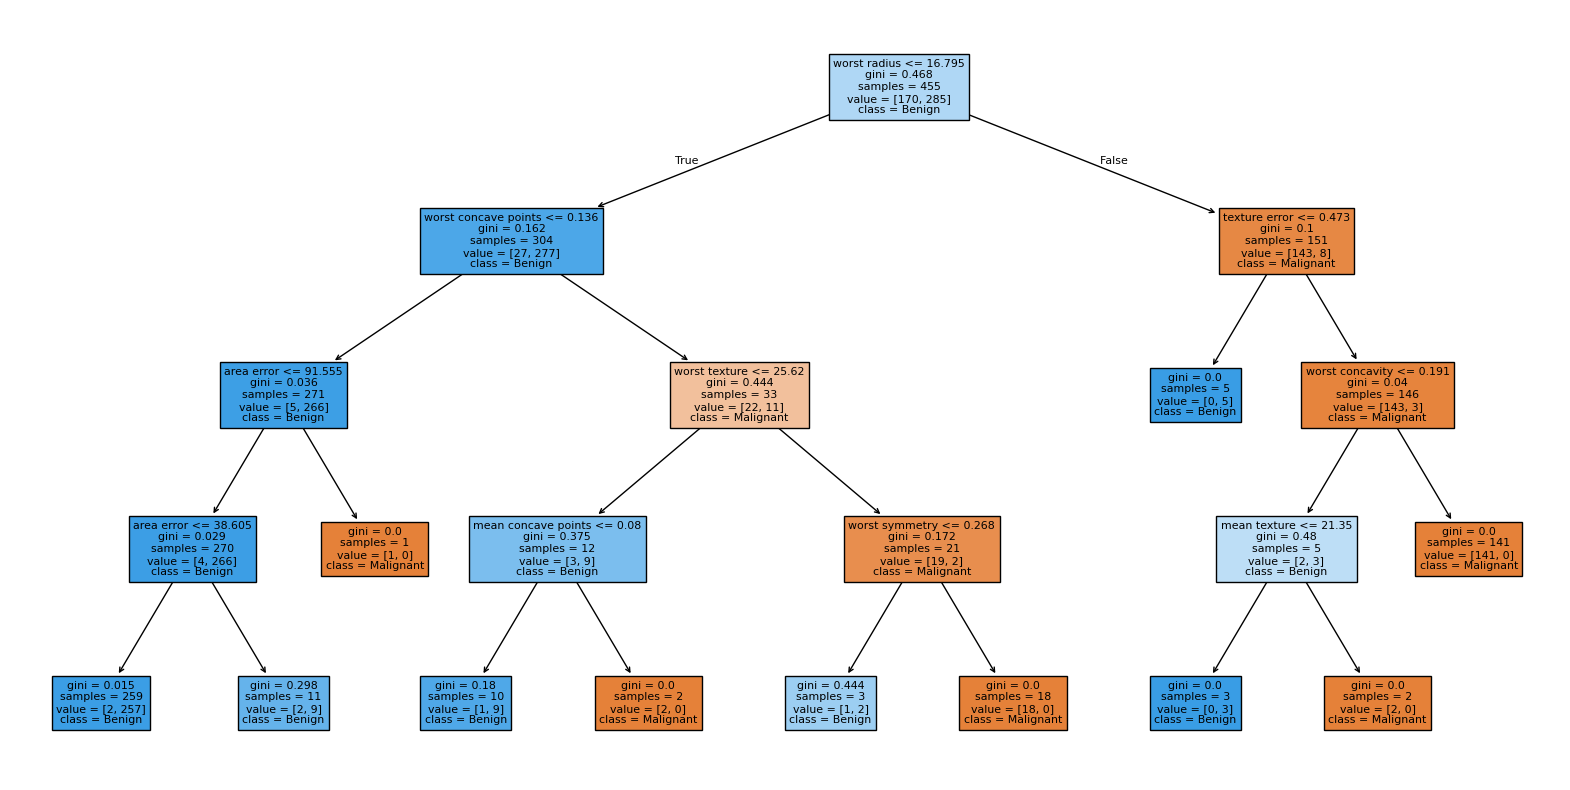

In [7]:
# Menampilkan visualisasi pohon keputusan
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True
)

plt.show()

Interpretasi Decision Tree

Decision Tree membentuk aturan keputusan secara bertahap berdasarkan fitur yang dianggap paling informatif. Setiap node menunjukkan kondisi tertentu yang digunakan model untuk memisahkan data ke dalam kategori Malignant atau Benign.

Visualisasi pohon keputusan memudahkan proses interpretasi karena aturan klasifikasi dapat dilihat secara langsung.

### Evaluasi dan Perbandingan Model

In [8]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

for name, y_pred in [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_tree)
]:

    print(f"\n=== {name} ===")

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")


=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


Pembahasan Hasil Evaluasi

Accuracy menunjukkan persentase prediksi yang benar dibandingkan seluruh data pengujian.

Precision menunjukkan tingkat ketepatan model ketika memberikan prediksi positif.

Recall menunjukkan kemampuan model dalam menemukan seluruh kasus positif yang sebenarnya ada pada data.

F1-Score merupakan nilai rata-rata harmonis antara Precision dan Recall sehingga dapat digunakan untuk melihat keseimbangan performa model.

Pada kasus diagnosis kanker, Recall menjadi metrik yang paling penting karena False Negative berarti pasien yang sebenarnya menderita kanker tidak terdeteksi oleh sistem. Kondisi tersebut dapat menyebabkan keterlambatan penanganan dan meningkatkan risiko bagi pasien.

Perbandingan Model

Berdasarkan hasil evaluasi yang diperoleh setelah notebook dijalankan, nilai Recall pada Logistic Regression adalah ........, sedangkan nilai Recall pada Decision Tree adalah ........ .

Model yang memiliki nilai Recall lebih tinggi lebih layak digunakan sebagai pendukung diagnosis awal kanker payudara karena mampu mengurangi kemungkinan kasus kanker yang terlewat (False Negative).

Selain Recall, perhatikan pula nilai Accuracy, Precision, dan F1-Score untuk mengetahui apakah terdapat perbedaan performa yang signifikan antara kedua model.

# Kesimpulan

Berdasarkan praktikum yang telah dilakukan, algoritma Logistic Regression dan Decision Tree dapat digunakan untuk melakukan klasifikasi diagnosis kanker payudara pada dataset Breast Cancer Wisconsin.

Tahap preprocessing melalui pembagian data training dan testing serta standardisasi fitur berhasil mempersiapkan data sebelum proses pelatihan model dilakukan.

Berdasarkan hasil evaluasi yang diperoleh setelah notebook dijalankan, model dengan nilai Recall tertinggi dapat dianggap lebih sesuai untuk digunakan sebagai pendukung diagnosis awal kanker payudara. Hal ini disebabkan Recall menunjukkan kemampuan model dalam mendeteksi seluruh pasien yang benar-benar menderita kanker sehingga risiko False Negative dapat diminimalkan.

Dengan demikian, pemilihan model pada kasus medis tidak hanya mempertimbangkan Accuracy, tetapi juga harus memperhatikan nilai Recall karena kesalahan dalam mendeteksi pasien yang menderita kanker dapat berdampak serius terhadap proses penanganan medis.